In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/00.05.csv")

In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 0,
    "bg_end_m": 3750,
    "overlap_r1_m": 850,
    "overlap_r2_m": 1350,
    "bin_shift": 0,
    "afterpulse_provided": True,
    "Sig_start": 3840,
    "Sig_end": 18836.25,
    "min_toggle_rate":0.5,
    "max_toggle_rate":10,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "overlap_function_r1_m": 50,
    "overlap_function_r2_m": 800,
    "overlap_function_k": 0.01,
    "overlap_min": 0.2,
    "energy_mJ":25
}


In [3]:
# add bin index and range
df.insert(0, "bin_index", np.arange(len(df)))
df.insert(1, "range_m", df["bin_index"] * config["bin_spacing_m"])

# keep original columns untouched
df["photon_counting_shifted"] = df["photon_counting"].shift(config["bin_shift"])
df["pc_sterr_shifted"] = df["pc_sterr"].shift(config["bin_shift"])

# optional: decide how to fill missing values created by shift
# df["photon_counting_shifted"] = df["photon_counting"].shift(bin_shift).fillna(0)
# df["pc_sterr_shifted"] = df["pc_sterr"].shift(bin_shift).fillna(np.nan)

# SNR
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting_shifted"] / df["pc_sterr_shifted"]

print(df.head())

   bin_index  range_m   analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00  5.67941      0.000580         0.033361  0.023509   
1          1     3.75  5.67969      0.000553         0.016681  0.016695   
2          2     7.50  5.67959      0.000552         0.000000  0.000000   
3          3    11.25  5.67965      0.000538         0.000000  0.000000   
4          4    15.00  5.67970      0.000545         0.016681  0.016695   

   overflow_info  photon_counting_shifted  pc_sterr_shifted    SNR_analog  \
0            0.0                 0.033361          0.023509   9797.863568   
1            0.0                 0.016681          0.016695  10278.865644   
2            0.0                 0.000000          0.000000  10296.853613   
3            0.0                 0.000000          0.000000  10547.990744   
4            0.0                 0.016681          0.016695  10429.773434   

   SNR_Photon  
0    1.419102  
1    0.999167  
2         NaN  
3         NaN  
4    0

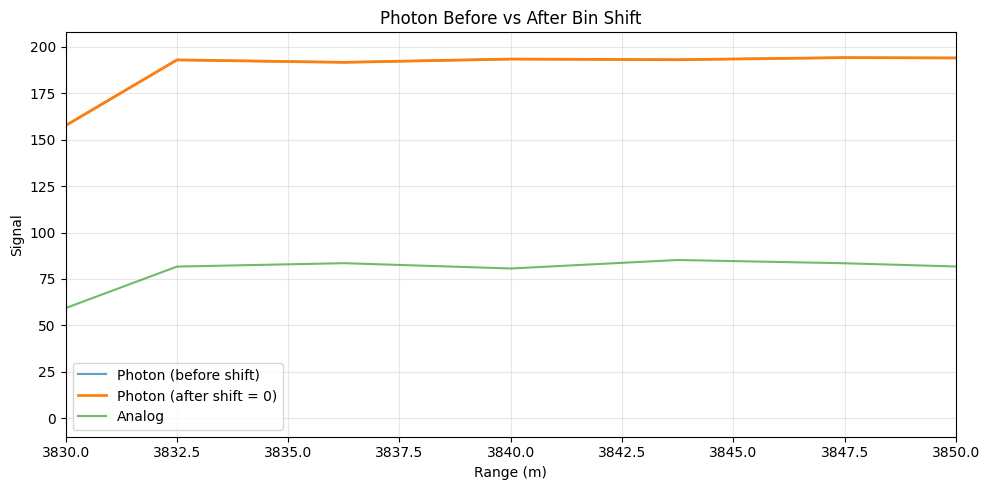

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# Before shift
ax.plot(
    df["range_m"],
    df["photon_counting"],
    label="Photon (before shift)",
    alpha=0.7
)

# After shift
ax.plot(
    df["range_m"],
    df["photon_counting_shifted"],
    label=f'Photon (after shift = {config["bin_shift"]})',
    linewidth=2
)

# Optional analog for reference
ax.plot(
    df["range_m"],
    df["analog"],
    label="Analog",
    alpha=0.7
)

ax.set_xlabel("Range (m)")
ax.set_xlim(3830,3850)
ax.set_ylabel("Signal")
ax.set_title("Photon Before vs After Bin Shift")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

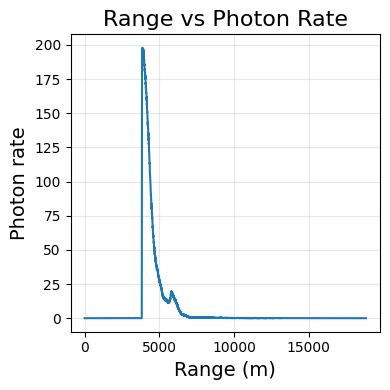

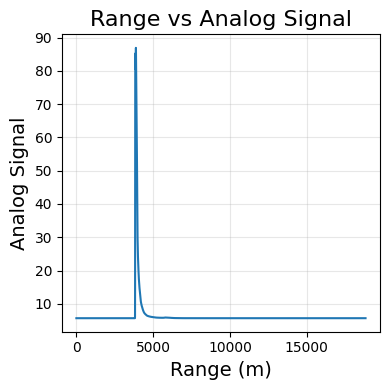

In [5]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    df,
    xcol="range_m",
    ycol="photon_counting_shifted",
    yscale="linear",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="range_vs_photon_rate.png",
)
#plot PhotonRate vs Range
plot_xy(
    df,
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="range_vs_Analog_Signal.png",
)

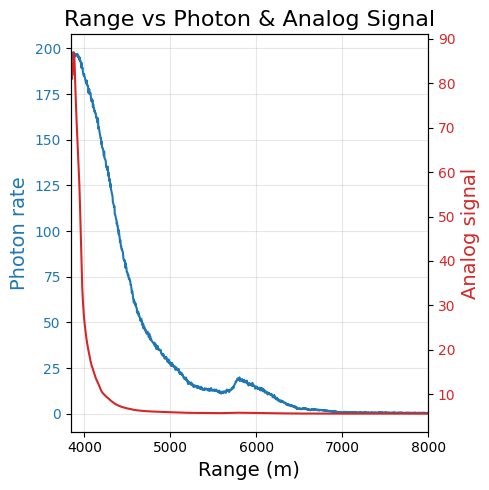

In [6]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting_shifted"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_xlim(3840, 8000)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
# Pre-calculate dead_time in seconds (ns * 1e-9)
dead_time_s = config["dead_time_ns"] * 1e-9

# Apply dead time correction to ALL bins
rate_meas_hz = df["photon_counting_shifted"] * 1e6
ratio = rate_meas_hz * dead_time_s
df["photon_deadtime_corr_hz"] = np.where(
    ratio < 1,
    rate_meas_hz / (1 - ratio),
    np.nan  # saturated
)
df["photon_deadtime_corr"] = df["photon_deadtime_corr_hz"] / 1e6

In [8]:
df_Sig = df[
        (df["range_m"] >= config["Sig_start"]) &
        (df["range_m"] <= config["Sig_end"])
    ].copy()

bg_region = df[
    (df["range_m"] >= config["bg_start_m"]) &
    (df["range_m"] <= config["bg_end_m"])
]

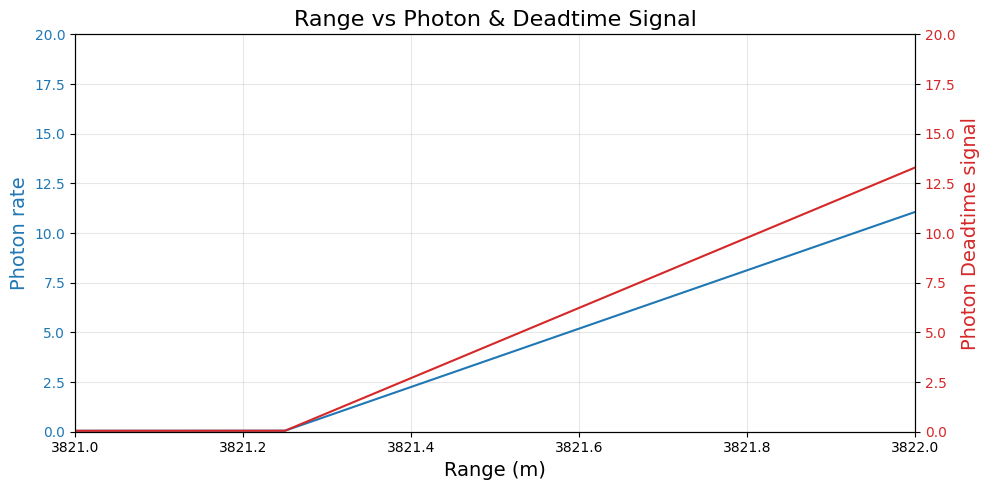

In [9]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting_shifted"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["photon_deadtime_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Photon Deadtime signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_ylim(0,20)
ax2.set_ylim(0,20)
ax1.set_xlim(3821,3822)
ax2.set_xlim(3821,3822)
plt.title("Range vs Photon & Deadtime Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [10]:
bg_region

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,SNR_Photon,photon_deadtime_corr_hz,photon_deadtime_corr
0,0,0.00,5.67941,0.000580,0.033361,0.023509,0.0,0.033361,0.023509,9797.863568,1.419102,33364.506014,0.033365
1,1,3.75,5.67969,0.000553,0.016681,0.016695,0.0,0.016681,0.016695,10278.865644,0.999167,16681.451465,0.016681
2,2,7.50,5.67959,0.000552,0.000000,0.000000,0.0,0.000000,0.000000,10296.853613,NaN,0.000000,0.000000
3,3,11.25,5.67965,0.000538,0.000000,0.000000,0.0,0.000000,0.000000,10547.990744,NaN,0.000000,0.000000
4,4,15.00,5.67970,0.000545,0.016681,0.016695,0.0,0.016681,0.016695,10429.773434,0.999167,16681.451465,0.016681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,3735.00,5.67945,0.000532,0.000000,0.000000,0.0,0.000000,0.000000,10666.054436,NaN,0.000000,0.000000
997,997,3738.75,5.67924,0.000553,0.016681,0.016695,0.0,0.016681,0.016695,10262.376130,0.999167,16681.451465,0.016681
998,998,3742.50,5.67886,0.000543,0.000000,0.000000,0.0,0.000000,0.000000,10458.170889,NaN,0.000000,0.000000
999,999,3746.25,5.67958,0.000555,0.016681,0.016695,0.0,0.016681,0.016695,10237.738590,0.999167,16681.451465,0.016681


In [11]:
# remove NaN / inf
bg_region = bg_region[
    np.isfinite(bg_region["analog"]) &
    np.isfinite(bg_region["photon_deadtime_corr_hz"])
]

Analog_bg_mean = bg_region["analog"].mean()
Photon_bg_mean = bg_region["photon_deadtime_corr"].mean()

In [12]:
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 5.6792512587412585
Photon Per Bin background (mean): 0.008832584167549453


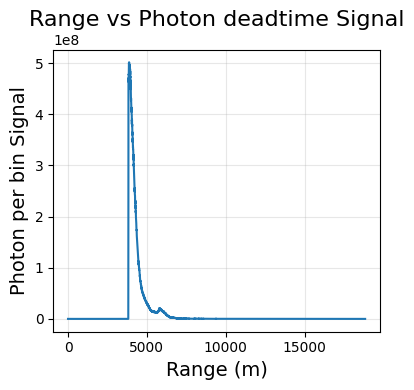

In [13]:
plot_xy(
    df,
    xcol="range_m",
    ycol="photon_deadtime_corr_hz",
    yscale="linear",
    title="Range vs Photon deadtime Signal",
    xlabel="Range (m)",
    ylabel="Photon per bin Signal",
    outfile="range_vs_PC_Signal.png",
)


In [14]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,SNR_Photon,photon_deadtime_corr_hz,photon_deadtime_corr
0,0,0.00,5.67941,0.000580,0.033361,0.023509,0.0,0.033361,0.023509,9.797864e+03,1.419102,33364.506014,0.033365
1,1,3.75,5.67969,0.000553,0.016681,0.016695,0.0,0.016681,0.016695,1.027887e+04,0.999167,16681.451465,0.016681
2,2,7.50,5.67959,0.000552,0.000000,0.000000,0.0,0.000000,0.000000,1.029685e+04,NaN,0.000000,0.000000
3,3,11.25,5.67965,0.000538,0.000000,0.000000,0.0,0.000000,0.000000,1.054799e+04,NaN,0.000000,0.000000
4,4,15.00,5.67970,0.000545,0.016681,0.016695,0.0,0.016681,0.016695,1.042977e+04,0.999167,16681.451465,0.016681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,5019,18821.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000,0.000000
5020,5020,18825.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,inf,16681.451465,0.016681
5021,5021,18828.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000,0.000000
5022,5022,18832.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,inf,33364.506014,0.033365


In [15]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,SNR_Photon,photon_deadtime_corr_hz,photon_deadtime_corr
1024,1024,3840.00,80.64670,0.234682,193.361000,0.866750,0.0,193.361000,0.866750,343.642461,223.087395,4.735580e+08,473.558010
1025,1025,3843.75,85.21870,0.245793,193.011000,0.882763,0.0,193.011000,0.882763,346.709223,218.644189,4.714642e+08,471.464192
1026,1026,3847.50,83.46120,0.237558,194.128000,0.902183,0.0,194.128000,0.902183,351.329781,215.175857,4.781851e+08,478.185096
1027,1027,3851.25,80.85830,0.204005,193.862000,0.898436,0.0,193.862000,0.898436,396.354501,215.777195,4.765743e+08,476.574348
1028,1028,3855.00,81.85130,0.177998,196.397000,0.898095,0.0,196.397000,0.898095,459.843931,218.681765,4.921920e+08,492.191997
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,5019,18821.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000
5020,5020,18825.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,inf,1.668145e+04,0.016681
5021,5021,18828.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000
5022,5022,18832.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,inf,3.336451e+04,0.033365


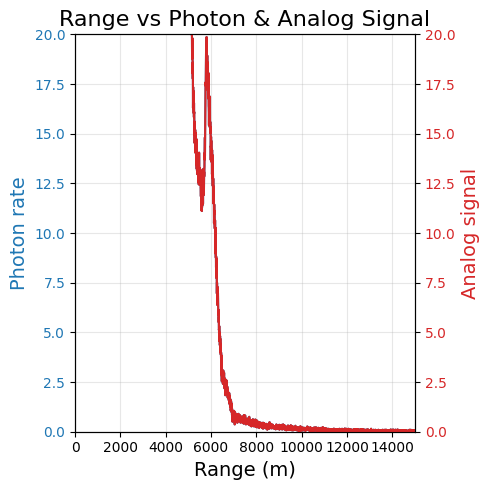

In [16]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["photon_counting_shifted"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["photon_counting"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_xlim(0,15000)
ax1.set_ylim(0,20)
ax2.set_xlim(0,15000)
ax2.set_ylim(0,20)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [17]:
 # re-zero bin_index and range
df_Sig["bin_index"] = df_Sig["bin_index"] - df_Sig["bin_index"].iloc[0]
df_Sig["range_m"] = df_Sig["bin_index"] * config["bin_spacing_m"]


df_Sig["analog_bg_corr"] = df_Sig["analog"] - Analog_bg_mean
df_Sig["photon_bg_corr"] = df_Sig["photon_deadtime_corr"] - Photon_bg_mean
df_Sig["photon_bg_corr"]

1024    473.549178
1025    471.455359
1026    478.176263
1027    476.565516
1028    492.183164
           ...    
5019     -0.008833
5020      0.007849
5021     -0.008833
5022      0.024532
5023     -0.008833
Name: photon_bg_corr, Length: 4000, dtype: float64

In [18]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,SNR_Photon,photon_deadtime_corr_hz,photon_deadtime_corr,analog_bg_corr,photon_bg_corr
1024,0,0.00,80.64670,0.234682,193.361000,0.866750,0.0,193.361000,0.866750,343.642461,223.087395,4.735580e+08,473.558010,74.967449,473.549178
1025,1,3.75,85.21870,0.245793,193.011000,0.882763,0.0,193.011000,0.882763,346.709223,218.644189,4.714642e+08,471.464192,79.539449,471.455359
1026,2,7.50,83.46120,0.237558,194.128000,0.902183,0.0,194.128000,0.902183,351.329781,215.175857,4.781851e+08,478.185096,77.781949,478.176263
1027,3,11.25,80.85830,0.204005,193.862000,0.898436,0.0,193.862000,0.898436,396.354501,215.777195,4.765743e+08,476.574348,75.179049,476.565516
1028,4,15.00,81.85130,0.177998,196.397000,0.898095,0.0,196.397000,0.898095,459.843931,218.681765,4.921920e+08,492.191997,76.172049,492.183164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000,0.000709,-0.008833
5020,3996,14985.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,inf,1.668145e+04,0.016681,-0.000321,0.007849
5021,3997,14988.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000,-0.000321,-0.008833
5022,3998,14992.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,inf,3.336451e+04,0.033365,0.000369,0.024532


In [19]:
def afterpulse_model(r, A1=80.0, tau1=40.0, A2=20.0, tau2=150.0):
    """
    Simple simulated afterpulse model.

    Parameters
    ----------
    r : array-like
        Range in meters.
    A1, A2 : float
        Amplitudes of fast and slow afterpulse components.
    tau1, tau2 : float
        Decay scales in meters.

    Returndf
    -------
    ap : ndarray
        Simulated afterpulse counts per bin.
    """
    r = np.asarray(r, dtype=float)
    ap = A1 * np.exp(-r / tau1) + A2 * np.exp(-r / tau2)
    return ap
    
df_Sig["afterpulse_sim"] = afterpulse_model(
    df_Sig["range_m"],
    A1=30.0,     # main afterpulse amplitude
    tau1=60.0,   # fast decay
    A2=8.0,      # slow component
    tau2=250.0   # long tail
)
df_Sig["photon_APcorr_counts"] = df["photon_deadtime_corr"] - df_Sig["afterpulse_sim"]

In [20]:
df["photon_deadtime_corr"]

0       0.033365
1       0.016681
2       0.000000
3       0.000000
4       0.016681
          ...   
5019    0.000000
5020    0.016681
5021    0.000000
5022    0.033365
5023    0.000000
Name: photon_deadtime_corr, Length: 5024, dtype: float64

In [21]:
df_Sig["range_m"]

1024        0.00
1025        3.75
1026        7.50
1027       11.25
1028       15.00
          ...   
5019    14981.25
5020    14985.00
5021    14988.75
5022    14992.50
5023    14996.25
Name: range_m, Length: 4000, dtype: float64

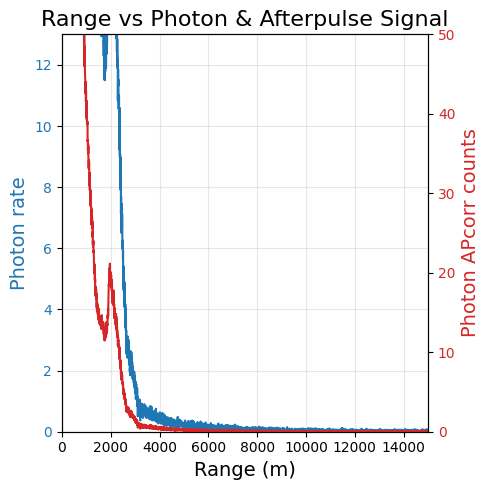

In [22]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["photon_deadtime_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["photon_APcorr_counts"], color="tab:red", label="Photon Afterpulse signal")
ax2.set_ylabel("Photon APcorr counts", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_xlim(0,15000)
ax1.set_ylim(0,13)
ax2.set_xlim(0,15000)
ax2.set_ylim(0,50)
plt.title("Range vs Photon & Afterpulse Signal", fontsize=16)
plt.tight_layout()
plt.show()


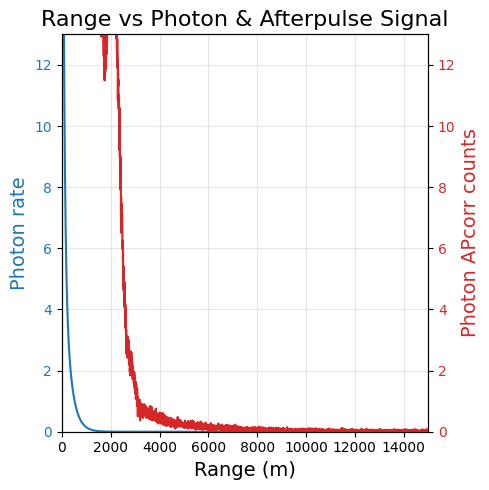

In [23]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["afterpulse_sim"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["photon_APcorr_counts"], color="tab:red", label="Photon Afterpulse signal")
ax2.set_ylabel("Photon APcorr counts", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_xlim(0,15000)
ax1.set_ylim(0,13)
ax2.set_xlim(0,15000)
ax2.set_ylim(0,13)
plt.title("Range vs Photon & Afterpulse Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [24]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,SNR_Photon,photon_deadtime_corr_hz,photon_deadtime_corr,analog_bg_corr,photon_bg_corr,afterpulse_sim,photon_APcorr_counts
1024,0,0.00,80.64670,0.234682,193.361000,0.866750,0.0,193.361000,0.866750,343.642461,223.087395,4.735580e+08,473.558010,74.967449,473.549178,3.800000e+01,4.355580e+02
1025,1,3.75,85.21870,0.245793,193.011000,0.882763,0.0,193.011000,0.882763,346.709223,218.644189,4.714642e+08,471.464192,79.539449,471.455359,3.606329e+01,4.354009e+02
1026,2,7.50,83.46120,0.237558,194.128000,0.902183,0.0,194.128000,0.902183,351.329781,215.175857,4.781851e+08,478.185096,77.781949,478.176263,3.423847e+01,4.439466e+02
1027,3,11.25,80.85830,0.204005,193.862000,0.898436,0.0,193.862000,0.898436,396.354501,215.777195,4.765743e+08,476.574348,75.179049,476.565516,3.251885e+01,4.440555e+02
1028,4,15.00,81.85130,0.177998,196.397000,0.898095,0.0,196.397000,0.898095,459.843931,218.681765,4.921920e+08,492.191997,76.172049,492.183164,3.089814e+01,4.612939e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000,0.000709,-0.008833,7.550803e-26,-7.550803e-26
5020,3996,14985.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,inf,1.668145e+04,0.016681,-0.000321,0.007849,7.438387e-26,1.668145e-02
5021,3997,14988.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,NaN,0.000000e+00,0.000000,-0.000321,-0.008833,7.327643e-26,-7.327643e-26
5022,3998,14992.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,inf,3.336451e+04,0.033365,0.000369,0.024532,7.218549e-26,3.336451e-02


In [25]:
# --- overlap window: select bins where BOTH signals are valid ---
# Per Licel manual: valid region is where dead-time corrected PC
# is between min_toggle_rate and max_toggle_rate (0.5–10 MHz)

mask_overlap = (
    (df_Sig["photon_deadtime_corr"] >= config["min_toggle_rate"]) &
    (df_Sig["photon_deadtime_corr"] <= config["max_toggle_rate"]) &
    np.isfinite(df_Sig["analog"]) &
    np.isfinite(df_Sig["photon_deadtime_corr"])
)

# mask_overlap = (
#     (df_Sig["photon_deadtime_corr"] >= config["min_toggle_rate"]) &
#     (df_Sig["photon_deadtime_corr"] <= config["max_toggle_rate"]) &
#     np.isfinite(df_Sig["analog_bg_corr"]) &
#     np.isfinite(df_Sig["photon_deadtime_corr"])
# )

m_overlap_valid = df_Sig.loc[mask_overlap, [
    "range_m",
    "analog",
    "photon_deadtime_corr"
]].copy()

print("valid rows for regression =", len(m_overlap_valid))
print("range of regression region: {:.1f} – {:.1f} m".format(
    m_overlap_valid["range_m"].min(),
    m_overlap_valid["range_m"].max()
))

if len(m_overlap_valid) < 2:
    print("Not enough valid points for regression.")
    k_scale = np.nan
    b_offset = np.nan
    df_Sig["analog_scaled_for_glue"] = np.nan
else:
    x = m_overlap_valid["analog"].to_numpy()
    y = m_overlap_valid["photon_deadtime_corr"].to_numpy()

    k_scale, b_offset, r, *_ = linregress(x, y)

    print("k_scale  =", k_scale)
    print("b_offset =", b_offset) 
    print("R²       =", r**2)

    # apply scale to the entire analog signal
    df_Sig["analog_scaled_for_glue"] = k_scale * df_Sig["analog"] + b_offset

valid rows for regression = 400
range of regression region: 2347.5 – 4200.0 m
k_scale  = 100.84530292712547
b_offset = -572.6821421788993
R²       = 0.9954250905555503


In [26]:
r = df_Sig["range_m"].to_numpy()
pc = df_Sig["photon_counting"].to_numpy()

analog = df_Sig["analog_scaled_for_glue"].to_numpy()
photon = df_Sig["photon_deadtime_corr"].to_numpy()

blend_r1 = config["overlap_r1_m"] - 100
blend_r2 = config["overlap_r2_m"] + 100
min_rate = config["min_toggle_rate"]
max_rate = config["max_toggle_rate"]

# default: use photon everywhere
w = np.ones_like(r, dtype=float)

# blend only in overlap region
m_blend = (r >= blend_r1) & (r <= blend_r2)
w[m_blend] = 0.5 * (
    1.0 - np.cos(np.pi * (r[m_blend] - blend_r1) / (blend_r2 - blend_r1))
)

# optional photon-rate override
w[pc > max_rate] = 0.0   # force analog
w[pc < min_rate] = 1.0   # force photon

df_Sig["weight_w"] = w

df_Sig["merged_sig"] = (
    (1.0 - w) * analog + w * photon
)


In [27]:
def overlap_logistic(
    r,
    *,
    r1=200.0,
    r2=300.0,
    k=0.08,
    min_overlap=0.2,
    clip=True
):
    """
    Logistic overlap function for lidar telescope–laser alignment.

    This models the incomplete transmitter–receiver overlap at short range.
    The function smoothly transitions from 0 to 1 between r1 and r2.

    Parameters
    ----------
    r : array-like or float
        Range values (meters).

    r1 : float
        Range where overlap starts to increase from ~0.
        Below this range the overlap is essentially incomplete.

    r2 : float
        Range where overlap becomes approximately complete (~1).

    k : float
        Logistic steepness parameter.
        Larger values make the transition sharper.

    min_overlap : float
        Minimum allowed overlap value to prevent division explosion
        during correction (signal / overlap).

    clip : bool
        If True, overlap values are clipped between [min_overlap, 1].

    Returns
    -------
    overlap : ndarray or float
        Overlap function O(r) between 0 and 1.
    """

    r = np.asarray(r, dtype=float)

    # midpoint of logistic transition
    r0 = 0.5 * (r1 + r2)

    # logistic function
    L = 1.0 / (1.0 + np.exp(-k * (r - r0)))

    # normalize logistic so that
    # overlap(r1) = 0
    # overlap(r2) = 1
    L1 = 1.0 / (1.0 + np.exp(-k * (r1 - r0)))
    L2 = 1.0 / (1.0 + np.exp(-k * (r2 - r0)))

    overlap = (L - L1) / (L2 - L1)

    # clip to physical bounds
    overlap = np.clip(overlap, 0.0, 1.0)

    # prevent division blow-up in correction
    if clip:
        overlap = np.maximum(overlap, min_overlap)

    return overlap
def overlap_function(R, theta_L, theta_R, d):
    # Convert divergence angles to beam radii
    r_laser = R * np.tan(theta_L / 2)
    r_receiver = R * np.tan(theta_R / 2)
    
    # Effective offset between beam centers at range R
    offset = d * (R / np.sqrt(R**2 + d**2))
    
    # Compute overlap of two circles (laser & receiver FOV)
    # using geometric circle intersection area
    def circle_overlap(a, b, c):
        if c >= a + b:
            return 0
        if c <= abs(a - b):
            return np.pi * min(a, b)**2
        part1 = a**2 * np.arccos((c**2 + a**2 - b**2)/(2*c*a))
        part2 = b**2 * np.arccos((c**2 + b**2 - a**2)/(2*c*b))
        part3 = 0.5 * np.sqrt((-c+a+b)*(c+a-b)*(c-a+b)*(c+a+b))
        return part1 + part2 - part3
    
    A_overlap = circle_overlap(r_laser, r_receiver, offset)
    A_laser = np.pi * r_laser**2
    return A_overlap / A_laser  # normalized overlap 0–1

In [28]:
# --- optical overlap correction ---
df_Sig["overlap_func"] = overlap_logistic(
    df_Sig["range_m"],
    r1=config["overlap_function_r1_m"],
    r2=config["overlap_function_r2_m"],
    k=config["overlap_function_k"],
    min_overlap=config["overlap_min"],
)

df_Sig["merged_counts_ovcorr"] = (
    df_Sig["merged_sig"] / df_Sig["overlap_func"]
)

# --- range^2 correction ---
df_Sig["range2_corrected_counts"] = (
    df_Sig["merged_sig"] * df_Sig["range_m"]**2
)
# --- range^2 correction Overlap---
df_Sig["range2_corrected_counts_overlap"] = (
    df_Sig["merged_counts_ovcorr"] * df_Sig["range_m"]**2
)

# --- energy normalization ---
E_joule = config["energy_mJ"] * 1e-3   # mJ -> J

df_Sig["nrb"] = df_Sig["range2_corrected_counts"] / E_joule

# --- optional max normalization for plotting only ---
max_val = np.nanmax(df_Sig["nrb"].to_numpy())
df_Sig["range2_norm"] = df_Sig["nrb"] / max_val

In [29]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,...,photon_APcorr_counts,analog_scaled_for_glue,weight_w,merged_sig,overlap_func,merged_counts_ovcorr,range2_corrected_counts,range2_corrected_counts_overlap,nrb,range2_norm
1024,0,0.00,80.64670,0.234682,193.361000,0.866750,0.0,193.361000,0.866750,343.642461,...,4.355580e+02,7560.158749,0.0,7560.158749,0.2,37800.793747,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1025,1,3.75,85.21870,0.245793,193.011000,0.882763,0.0,193.011000,0.882763,346.709223,...,4.354009e+02,8021.223474,0.0,8021.223474,0.2,40106.117372,1.127985e+05,5.639923e+05,4.511938e+06,0.001393
1026,2,7.50,83.46120,0.237558,194.128000,0.902183,0.0,194.128000,0.902183,351.329781,...,4.439466e+02,7843.987854,0.0,7843.987854,0.2,39219.939272,4.412243e+05,2.206122e+06,1.764897e+07,0.005448
1027,3,11.25,80.85830,0.204005,193.862000,0.898436,0.0,193.862000,0.898436,396.354501,...,4.440555e+02,7581.497615,0.0,7581.497615,0.2,37907.488077,9.595333e+05,4.797666e+06,3.838133e+07,0.011847
1028,4,15.00,81.85130,0.177998,196.397000,0.898095,0.0,196.397000,0.898095,459.843931,...,4.612939e+02,7681.637001,0.0,7681.637001,0.2,38408.185007,1.728368e+06,8.641842e+06,6.913473e+07,0.021339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,...,-7.550803e-26,0.115145,1.0,0.000000,1.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
5020,3996,14985.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,...,1.668145e-02,0.011274,1.0,0.016681,1.0,0.016681,3.745824e+06,3.745824e+06,1.498329e+08,0.046248
5021,3997,14988.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,...,-7.327643e-26,0.011274,1.0,0.000000,1.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
5022,3998,14992.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,...,3.336451e-02,0.080857,1.0,0.033365,1.0,0.033365,7.499509e+06,7.499509e+06,2.999803e+08,0.092592


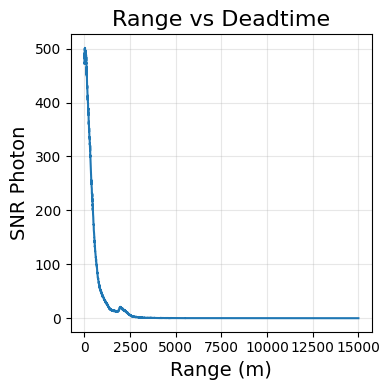

In [30]:
plot_xy(
    df_Sig,
    xcol="range_m",
    ycol="photon_deadtime_corr",
    yscale="linear",
    title="Range vs Deadtime",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="range_vs_SNR_Photon.png",
)

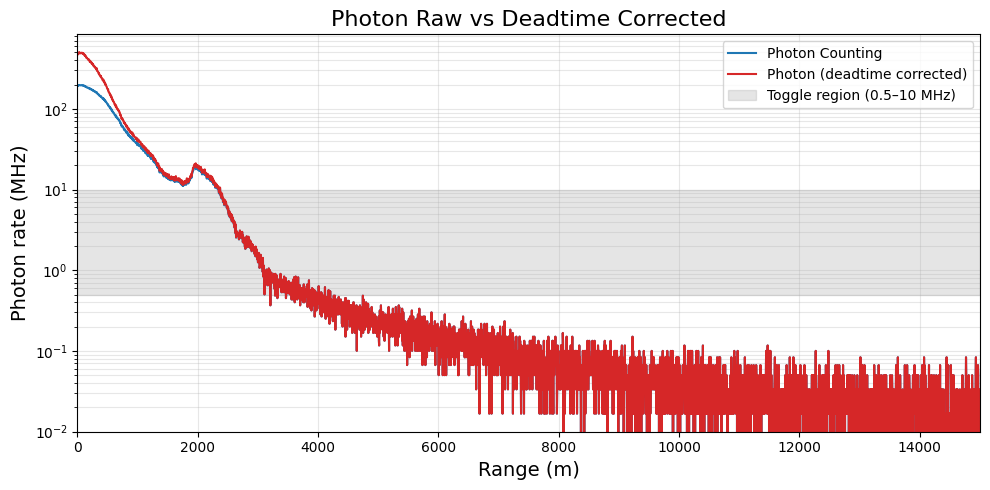

In [31]:
fig, ax = plt.subplots(figsize=(10,5))

# --- Photon raw ---
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_counting"],
    color="tab:blue",
    label="Photon Counting"
)

# --- Photon deadtime corrected ---
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_deadtime_corr"],
    color="tab:red",
    label="Photon (deadtime corrected)"
)

# --- Toggle region 0.5–10 MHz ---
ax.axhspan(
    0.5,
    10,
    color="gray",
    alpha=0.2,
    label="Toggle region (0.5–10 MHz)"
)

ax.set_xlabel("Range (m)", fontsize=14)
ax.set_ylabel("Photon rate (MHz)", fontsize=14)

ax.set_xlim(0, 15000)

# แนะนำสำหรับ lidar
ax.set_yscale("log")

ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")

plt.title("Photon Raw vs Deadtime Corrected", fontsize=16)
plt.tight_layout()
plt.show()

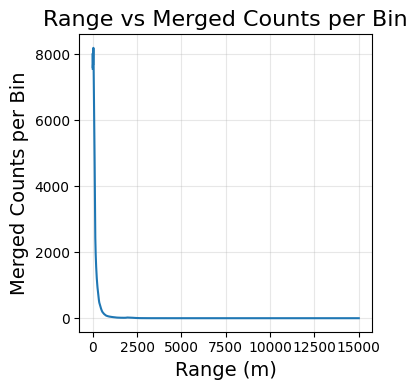

In [32]:
plot_xy(
    df_Sig,
    xcol="range_m",
    ycol="merged_sig",
    yscale="linear",
    title="Range vs Merged Counts per Bin",
    xlabel="Range (m)",
    ylabel="Merged Counts per Bin",
    outfile="range_vs_merged_counts_per_bin.png",
)

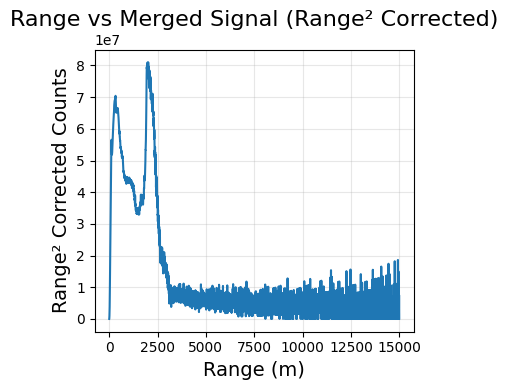

In [33]:
plot_xy(
    df_Sig,
    xcol="range_m",
    ycol="range2_corrected_counts",
    yscale="linear",
    title="Range vs Merged Signal (Range² Corrected)",
    xlabel="Range (m)",
    ylabel="Range² Corrected Counts",
    outfile="range_vs_merged_counts_per_bin.png",
)

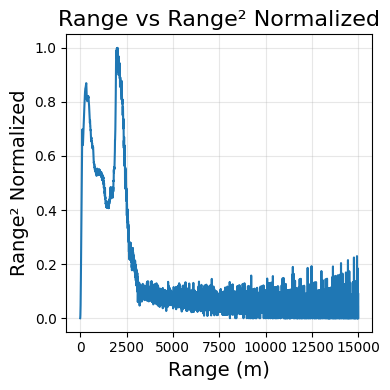

In [34]:
plot_xy(
    df_Sig,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Range² Normalized",
    xlabel="Range (m)",
    ylabel="Range² Normalized",
    outfile="range_vs_Range2_Normalized.png",
)

In [35]:
#MiniMPL
MiniMPL = pd.read_csv("MPL_5038_202603250001.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [36]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range_m": MiniMPL["range_raw"]*1000,
    "range_NRB": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize_copol_nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202603250001.csv", index=False)

In [37]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202603250001.csv")
MiniMPL_for_process

,range_raw,range_m,range_NRB,copol_raw,copol_snr,copol_nrb,pbls,Normalize_copol_nrb
0,0.029979,29.979246,119.91698,26.599525,88675.570000,0.500656,0.209855,1.000000
1,0.059958,59.958490,149.89623,20.415470,67961.600000,0.408631,NaN,0.816191
2,0.089938,89.937740,179.87548,20.973629,69819.720000,0.377018,NaN,0.753048
3,0.119917,119.916980,209.85472,17.392458,58088.750000,0.359539,NaN,0.718135
4,0.149896,149.896230,239.83397,13.673345,45643.547000,0.354540,NaN,0.708151
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000565,-0.494595,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000773,0.202073,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000684,-0.106710,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000699,-0.029548,NaN,NaN,NaN


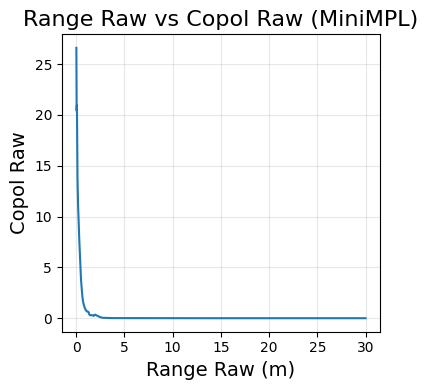

In [38]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_raw",
    yscale="linear",
    title="Range Raw vs Copol Raw (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol Raw",
    outfile="Range_Raw_vs_Copol_Raw(MiniMPL).png",
)

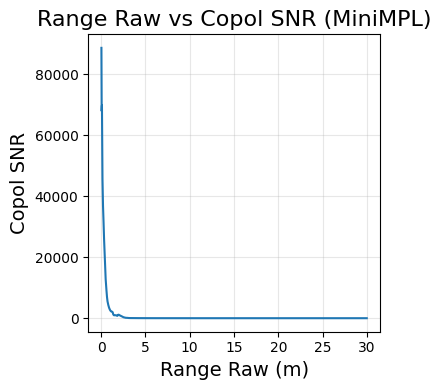

In [39]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_snr",
    yscale="linear",
    title="Range Raw vs Copol SNR (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol SNR",
    outfile="Range_Raw_vs_Copol_SNR(MiniMPL).png",
)

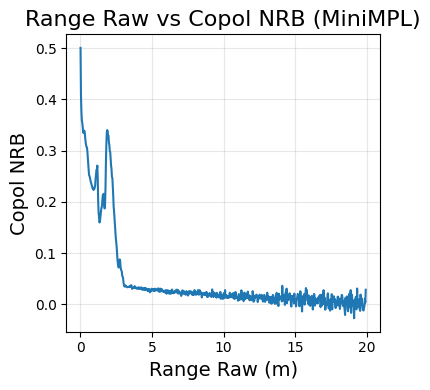

In [40]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_nrb",
    yscale="linear",
    title="Range Raw vs Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol NRB",
    outfile="Range_Raw_vs_Copol_NRB(MiniMPL).png",
)

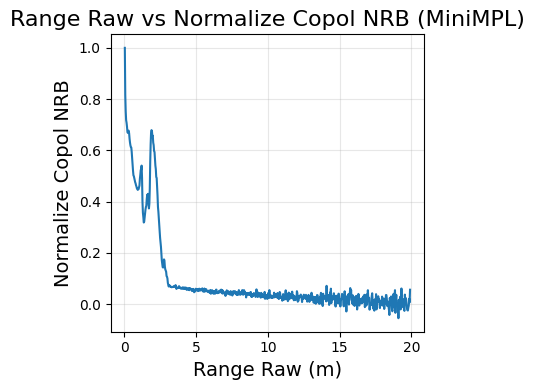

In [41]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="Normalize_copol_nrb",
    yscale="linear",
    title="Range Raw vs Normalize Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Normalize Copol NRB",
    outfile="Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
)

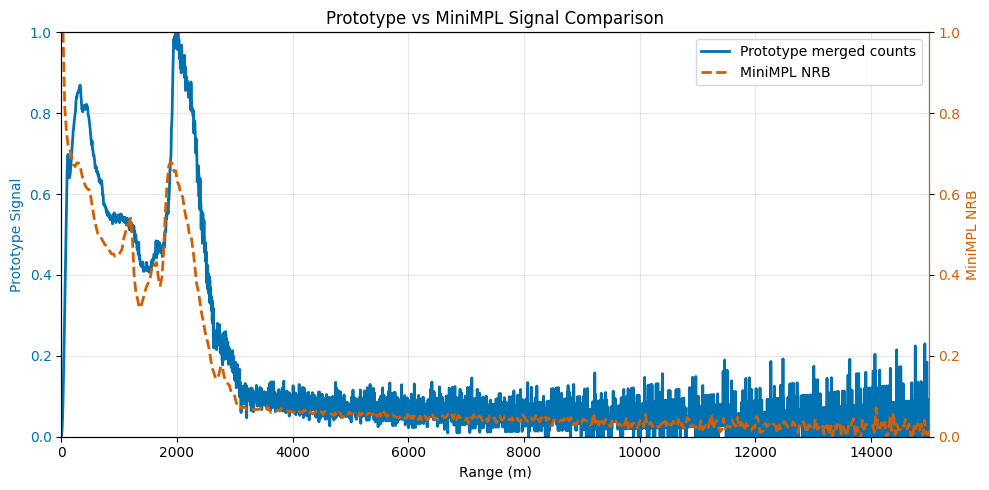

In [42]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Choose colors
color1 = "#0072B2"   # blue → Prototype
color2 = "#D55E00"   # orange → MiniMPL

# Left Y-axis → Prototype
ax1.plot(
    df_Sig["range_m"],
    df_Sig["range2_norm"],
    color=color1,
    linewidth=2,
    label="Prototype merged counts",
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Signal", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0,1)
ax1.spines["left"].set_color(color1)
ax1.grid(True, alpha=0.3)

# Right Y-axis → MiniMPL
ax2 = ax1.twinx()
ax2.plot(
    MiniMPL_for_process["range_m"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    color=color2,
    linewidth=2,
    linestyle="--",
    label="MiniMPL NRB",
)
ax2.set_ylabel("MiniMPL NRB", color=color2)
ax2.set_ylim(0,1)
ax2.set_xlim(0, 15000)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.spines["right"].set_color(color2)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Prototype vs MiniMPL Signal Comparison")
plt.tight_layout()
plt.show()

In [43]:
MiniMPL_for_process["range_m"]

0         29.979246
1         59.958490
2         89.937740
3        119.916980
4        149.896230
           ...     
995    29859.330000
996    29889.309000
997    29919.287000
998    29949.266000
999    29979.246000
Name: range_m, Length: 1000, dtype: float64

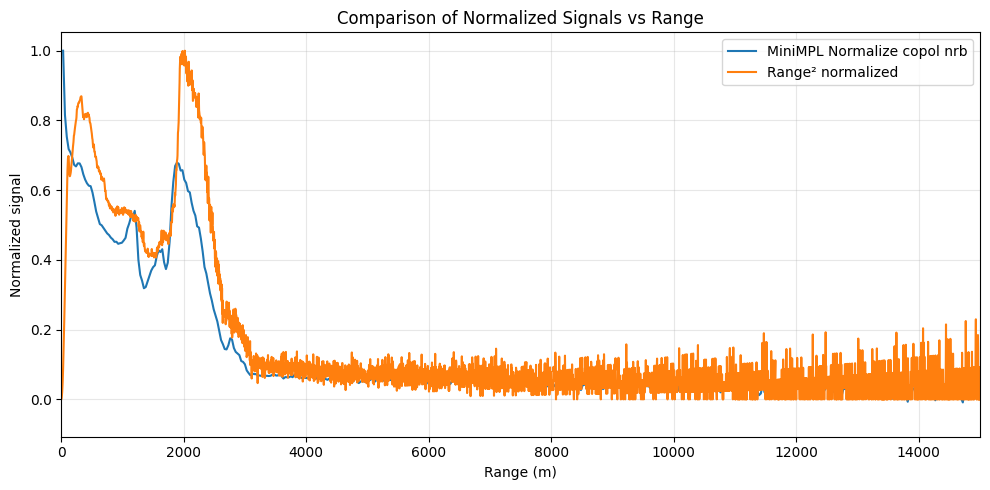

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    MiniMPL_for_process["range_m"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    label="MiniMPL Normalize copol nrb",
)

plt.plot(
    df_Sig["range_m"],
    df_Sig["range2_norm"],
    label="Range² normalized",
)
plt.xlim(0, 15000)   # example: 0–8 km
plt.xlabel("Range (m)")
plt.ylabel("Normalized signal")
plt.title("Comparison of Normalized Signals vs Range")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale("linear")

plt.tight_layout()
plt.show()

In [45]:
df_Sig[["range_m", "range2_norm"]].to_csv(
    "range2_norm_output.csv",
    index=False
)
df_Sig[["range_m", "merged_sig"]].to_csv(
    "glue_output.csv",
    index=False
)

In [46]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,...,photon_APcorr_counts,analog_scaled_for_glue,weight_w,merged_sig,overlap_func,merged_counts_ovcorr,range2_corrected_counts,range2_corrected_counts_overlap,nrb,range2_norm
1024,0,0.00,80.64670,0.234682,193.361000,0.866750,0.0,193.361000,0.866750,343.642461,...,4.355580e+02,7560.158749,0.0,7560.158749,0.2,37800.793747,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1025,1,3.75,85.21870,0.245793,193.011000,0.882763,0.0,193.011000,0.882763,346.709223,...,4.354009e+02,8021.223474,0.0,8021.223474,0.2,40106.117372,1.127985e+05,5.639923e+05,4.511938e+06,0.001393
1026,2,7.50,83.46120,0.237558,194.128000,0.902183,0.0,194.128000,0.902183,351.329781,...,4.439466e+02,7843.987854,0.0,7843.987854,0.2,39219.939272,4.412243e+05,2.206122e+06,1.764897e+07,0.005448
1027,3,11.25,80.85830,0.204005,193.862000,0.898436,0.0,193.862000,0.898436,396.354501,...,4.440555e+02,7581.497615,0.0,7581.497615,0.2,37907.488077,9.595333e+05,4.797666e+06,3.838133e+07,0.011847
1028,4,15.00,81.85130,0.177998,196.397000,0.898095,0.0,196.397000,0.898095,459.843931,...,4.612939e+02,7681.637001,0.0,7681.637001,0.2,38408.185007,1.728368e+06,8.641842e+06,6.913473e+07,0.021339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67996,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,...,-7.550803e-26,0.115145,1.0,0.000000,1.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
5020,3996,14985.00,5.67893,0.000000,0.016681,0.000000,0.0,0.016681,0.000000,inf,...,1.668145e-02,0.011274,1.0,0.016681,1.0,0.016681,3.745824e+06,3.745824e+06,1.498329e+08,0.046248
5021,3997,14988.75,5.67893,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,inf,...,-7.327643e-26,0.011274,1.0,0.000000,1.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
5022,3998,14992.50,5.67962,0.000000,0.033361,0.000000,0.0,0.033361,0.000000,inf,...,3.336451e-02,0.080857,1.0,0.033365,1.0,0.033365,7.499509e+06,7.499509e+06,2.999803e+08,0.092592


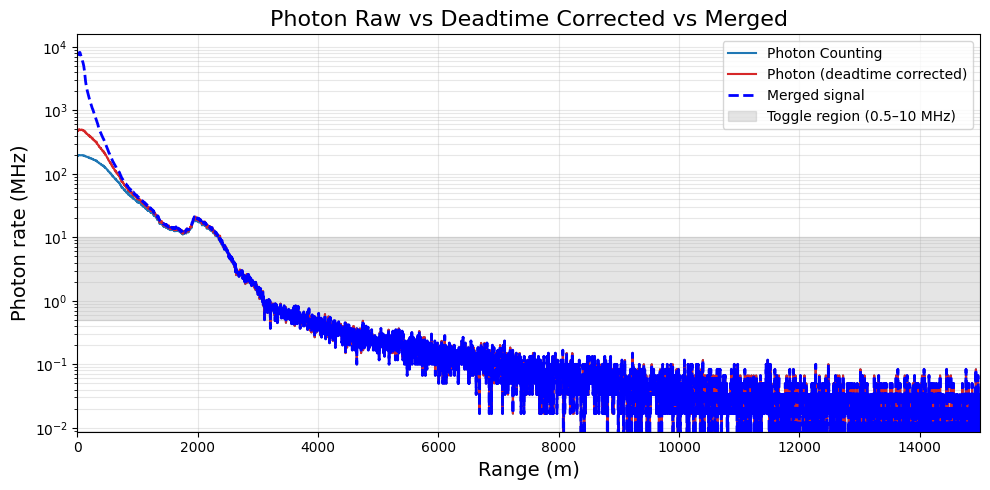

In [47]:
# bin_width_s = config["bin_width_ns"] * 1e-9

# convert merged counts/bin -> MHz
# merged_rate_mhz = df_Sig["merged_counts_per_bin"] / bin_width_s / 1e6
merged_rate_mhz = df_Sig["merged_sig"]

fig, ax = plt.subplots(figsize=(10,5))

# Photon raw
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_counting"],
    color="tab:blue",
    label="Photon Counting"
)

# Deadtime corrected
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_deadtime_corr"],
    color="tab:red",
    label="Photon (deadtime corrected)"
)

# Merged signal
ax.plot(
    df_Sig["range_m"],
    merged_rate_mhz,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Merged signal"
)

# Toggle region
ax.axhspan(
    0.5,
    10,
    color="gray",
    alpha=0.2,
    label="Toggle region (0.5–10 MHz)"
)

ax.set_xlabel("Range (m)", fontsize=14)
ax.set_ylabel("Photon rate (MHz)", fontsize=14)

ax.set_xlim(0, 15000)
ax.set_yscale("log")

ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")

plt.title("Photon Raw vs Deadtime Corrected vs Merged", fontsize=16)
plt.tight_layout()
plt.show()

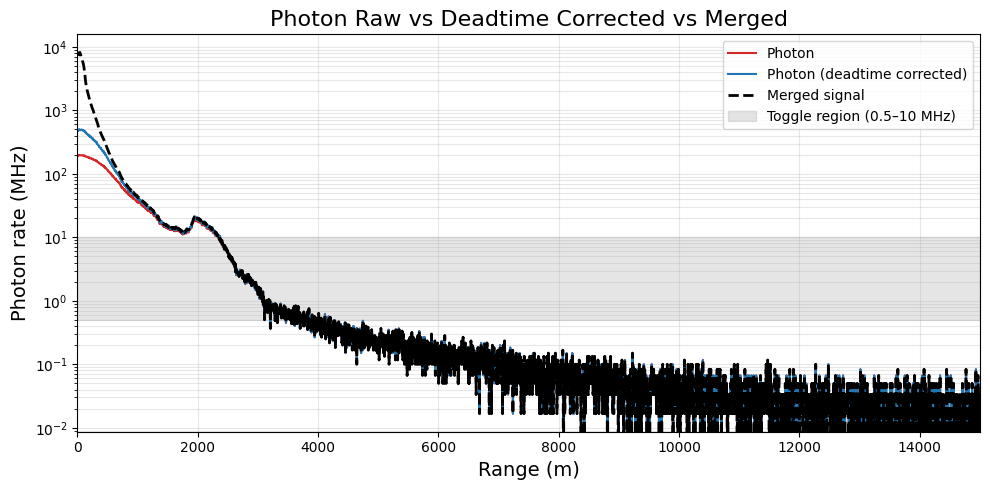

In [48]:
fig, ax = plt.subplots(figsize=(10,5))

# Photon raw
# ax.plot(
#     df_Sig["range_m"],
#     df_Sig["photon_counting"],
#     color="tab:blue",
#     label="Photon Counting"
# )

# Deadtime corrected
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_counting"],
    color="tab:red",
    label="Photon"
)
ax.plot(
    df_Sig["range_m"],
    df_Sig["photon_deadtime_corr"],
    color="tab:blue",
    label="Photon (deadtime corrected)"
)

# Merged signal
ax.plot(
    df_Sig["range_m"],
    merged_rate_mhz,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged signal"
)

# Toggle region
ax.axhspan(
    0.5,
    10,
    color="gray",
    alpha=0.2,
    label="Toggle region (0.5–10 MHz)"
)

ax.set_xlabel("Range (m)", fontsize=14)
ax.set_ylabel("Photon rate (MHz)", fontsize=14)

ax.set_xlim(0, 15000)
ax.set_yscale("log")

ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")

plt.title("Photon Raw vs Deadtime Corrected vs Merged", fontsize=16)
plt.tight_layout()
plt.show()

In [49]:
df_Sig.head()

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,pc_sterr_shifted,SNR_analog,...,photon_APcorr_counts,analog_scaled_for_glue,weight_w,merged_sig,overlap_func,merged_counts_ovcorr,range2_corrected_counts,range2_corrected_counts_overlap,nrb,range2_norm
1024,0,0.00,80.6467,0.234682,193.361,0.866750,0.0,193.361,0.866750,343.642461,...,435.558010,7560.158749,0.0,7560.158749,0.2,37800.793747,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1025,1,3.75,85.2187,0.245793,193.011,0.882763,0.0,193.011,0.882763,346.709223,...,435.400905,8021.223474,0.0,8021.223474,0.2,40106.117372,1.127985e+05,5.639923e+05,4.511938e+06,0.001393
1026,2,7.50,83.4612,0.237558,194.128,0.902183,0.0,194.128,0.902183,351.329781,...,443.946624,7843.987854,0.0,7843.987854,0.2,39219.939272,4.412243e+05,2.206122e+06,1.764897e+07,0.005448
1027,3,11.25,80.8583,0.204005,193.862,0.898436,0.0,193.862,0.898436,396.354501,...,444.055495,7581.497615,0.0,7581.497615,0.2,37907.488077,9.595333e+05,4.797666e+06,3.838133e+07,0.011847
1028,4,15.00,81.8513,0.177998,196.397,0.898095,0.0,196.397,0.898095,459.843931,...,461.293857,7681.637001,0.0,7681.637001,0.2,38408.185007,1.728368e+06,8.641842e+06,6.913473e+07,0.021339


In [123]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def auto_detect_overlap_region(
    df,
    analog_col="analog",
    photon_col="photon_counting",
    range_col="range_m",
    r_min=100,
    r_max=5000,
    window_m=500,
    step_m=25,
    min_points=20,
    r2_min=0.95,
):
    results = []
    for start in np.arange(r_min, r_max - window_m + step_m, step_m):
        end = start + window_m
        d = df[
            (df[range_col] >= start) &
            (df[range_col] <= end)
        ][[range_col, analog_col, photon_col]].copy()

        # clean
        d = d.replace([np.inf, -np.inf], np.nan).dropna()
        d = d[(d[analog_col] > 0) & (d[photon_col] > 0)]
        if len(d) < min_points:
            continue

        x = d[analog_col].to_numpy()
        y = d[photon_col].to_numpy()
        slope, intercept, r, p, stderr = linregress(x, y)
        r2 = r**2

        y_fit = slope * x + intercept
        rmse = np.sqrt(np.mean((y - y_fit)**2))
        rel_rmse = rmse / np.mean(y)

        results.append({
            "start_m": start,
            "end_m": end,
            "n_points": len(d),
            "slope": slope,
            "intercept": intercept,
            "r2": r2,
            "rel_rmse": rel_rmse,
        })

    if not results:           # ← check BEFORE making DataFrame
        return None, None

    results_df = pd.DataFrame(results)

    # ── Slope stability filter (rolling std over 5 neighbours) ──────────
    results_df["slope_rolling_std"] = (
        results_df["slope"]
        .rolling(window=5, center=True)
        .std()
    )

    global_slope_std = results_df["slope"].std()

    # ── Combined candidate filter (R² + positive slope + stability) ─────
    candidates = results_df[
        (results_df["slope"] > 0) &
        (results_df["r2"] >= r2_min) &
        (results_df["slope_rolling_std"] < global_slope_std * 0.3)  # ← stability
    ].copy()

    if candidates.empty:
        # fallback 1: drop stability requirement, keep R² + slope
        candidates = results_df[
            (results_df["slope"] > 0) &
            (results_df["r2"] >= r2_min)
        ].copy()

    if candidates.empty:
        # fallback 2: just pick highest R² from everything
        best = results_df.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]
    else:
        best = candidates.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]

    return best, results_df


best, scan_table = auto_detect_overlap_region(
    df_Sig,
    r_min=100,
    r_max=5000,
    window_m=150,
    step_m=25,
    min_points=20,
    r2_min=0.95,
)
print(best)

start_m              650.000000
end_m                800.000000
n_points              40.000000
slope                 49.619871
intercept           -262.363284
r2                     0.991757
rel_rmse               0.010928
slope_rolling_std      3.879957
Name: 22, dtype: float64


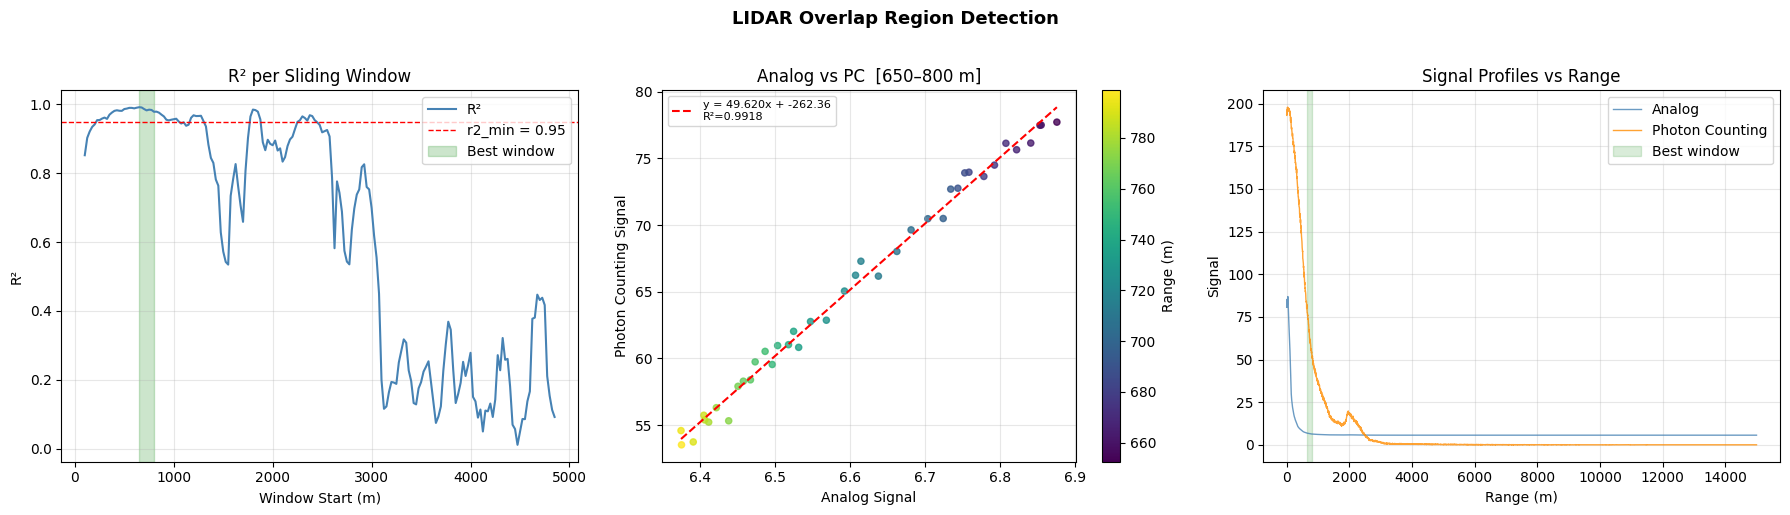

In [125]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. R² across all scanned windows ──────────────────────────────────────
ax1 = axes[0]
ax1.plot(scan_table["start_m"], scan_table["r2"], color="steelblue", lw=1.5, label="R²")
ax1.axhline(0.95, color="red", ls="--", lw=1, label="r2_min = 0.95")
if best is not None:
    ax1.axvspan(best["start_m"], best["end_m"], alpha=0.2, color="green", label="Best window")
ax1.set_xlabel("Window Start (m)")
ax1.set_ylabel("R²")
ax1.set_title("R² per Sliding Window")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Analog vs Photon Counting — best window only ───────────────────────
ax2 = axes[1]
if best is not None:
    d_best = df_Sig[
        (df_Sig["range_m"] >= best["start_m"]) &
        (df_Sig["range_m"] <= best["end_m"])
    ].replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
    d_best = d_best[(d_best["analog"] > 0) & (d_best["photon_counting"] > 0)]

    ax2.scatter(d_best["analog"], d_best["photon_counting"],
                c=d_best["range_m"], cmap="viridis", s=20, alpha=0.8)

    # fitted line
    x_line = np.linspace(d_best["analog"].min(), d_best["analog"].max(), 200)
    y_line = best["slope"] * x_line + best["intercept"]
    ax2.plot(x_line, y_line, "r--", lw=1.5,
             label=f"y = {best['slope']:.3f}x + {best['intercept']:.2f}\nR²={best['r2']:.4f}")

    sm = cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(d_best["range_m"].min(), d_best["range_m"].max()))
    plt.colorbar(sm, ax=ax2, label="Range (m)")
    ax2.set_xlabel("Analog Signal")
    ax2.set_ylabel("Photon Counting Signal")
    ax2.set_title(f"Analog vs PC  [{best['start_m']:.0f}–{best['end_m']:.0f} m]")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

# ── 3. Both signals vs Range — full profile ───────────────────────────────
ax3 = axes[2]
df_clean = df_Sig.replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
df_clean = df_clean[(df_clean["analog"] > 0) & (df_clean["photon_counting"] > 0)]

ax3.plot(df_clean["range_m"], df_clean["analog"],
         color="steelblue", lw=1, alpha=0.8, label="Analog")
ax3.plot(df_clean["range_m"], df_clean["photon_counting"],
         color="darkorange", lw=1, alpha=0.8, label="Photon Counting")

if best is not None:
    ax3.axvspan(best["start_m"], best["end_m"], alpha=0.15, color="green", label="Best window")

ax3.set_xlabel("Range (m)")
ax3.set_ylabel("Signal")
ax3.set_title("Signal Profiles vs Range")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle("LIDAR Overlap Region Detection", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()